# Projeto AGEMC — Predição de Churn

Este notebook reúne o desenvolvimento do projeto da disciplina de Pensamento Analítico de Dados, seguindo o processo **AGEMC**:

- **A — Ask an interesting question**
- **G — Get the data**
- **E — Explore the data**
- **M — Model the data**
- **C — Communicate and visualize the results**

Neste primeiro momento, o notebook contém apenas as três primeiras etapas: **Ask**, **Get** e **Explore**. A originalidade do projeto será introduzida futuramente na etapa **Model**.

## Contexto do projeto

O Projeto FMF escolhido é uma aplicação de aprendizado de máquina para **predição de churn de clientes de telecomunicações**. O problema consiste em prever se um cliente irá cancelar o serviço a partir de características de uso, planos contratados e interações com atendimento.

No nosso projeto, as etapas **Ask**, **Get** e **Explore** seguem o mesmo caminho do Projeto FMF. A contribuição original será aplicada posteriormente na etapa **Model**, e a etapa **Communicate** será afetada pelos resultados dessa modelagem.

## Preparação do ambiente

As células abaixo carregam as bibliotecas, localizam o arquivo de dados e configuram opções básicas de visualização.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "CustomerChurnData.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "CustomerChurnData.csv"
DATA_PATH

WindowsPath('C:/Users/tbail/OneDrive/Documentos/UFG/PAD/data/CustomerChurnData.csv')

# A — Ask an Interesting Question

## Pergunta científica

**É possível prever, a partir do comportamento de uso e do perfil de assinatura de um cliente de telecomunicações, se ele irá cancelar o serviço antes que o cancelamento aconteça?**

O objetivo científico é identificar padrões que diferenciam clientes que cancelam daqueles que permanecem, permitindo construir um modelo capaz de estimar a probabilidade de churn para clientes novos ou ativos.

## O que o projeto deseja prever?

A variável-alvo é `churn`, uma variável binária:

- `False`: o cliente permaneceu;
- `True`: o cliente cancelou.

A previsão dessa variável pode apoiar ações de retenção, como ofertas personalizadas, melhorias no atendimento e priorização de clientes com maior risco de cancelamento.

# G — Get the Data

## Fonte dos dados

O dataset utilizado é o **Churn in Telecom's Dataset**, associado ao caso SyriaTel. A fonte primária é o Kaggle, e o arquivo usado no Projeto FMF também está disponível no repositório da autora de referência.

- Fonte primária: https://www.kaggle.com/datasets/becksddf/churn-in-telecoms-dataset
- Fonte usada como referência FMF: https://github.com/GraceMwende/Customer-Churn
- Arquivo local: `data/CustomerChurnData.csv`

In [2]:
df = pd.read_csv(DATA_PATH)

if df["churn"].dtype == "object":
    df["churn"] = df["churn"].map({"True": True, "False": False})

df.shape

(3333, 21)

In [3]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.10,110,45.07,197.40,99,16.78,244.70,91,11.01,10.00,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.60,123,27.47,195.50,103,16.62,254.40,103,11.45,13.70,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.40,114,41.38,121.20,110,10.30,162.60,104,7.32,12.20,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.40,71,50.90,61.90,88,5.26,196.90,89,8.86,6.60,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.70,113,28.34,148.30,122,12.61,186.90,121,8.41,10.10,3,2.73,3,False


In [4]:
data_quality = pd.DataFrame(
    {
        "indicador": ["linhas", "colunas", "valores ausentes", "linhas duplicadas"],
        "valor": [df.shape[0], df.shape[1], int(df.isna().sum().sum()), int(df.duplicated().sum())],
    }
)

data_quality

,indicador,valor
0,linhas,3333
1,colunas,21
2,valores ausentes,0
3,linhas duplicadas,0


## Privacidade e seleção inicial

A coluna `phone number` funciona como identificador e deve ser removida antes da modelagem, tanto por baixa utilidade preditiva quanto por boa prática de minimização de dados. As colunas de cobrança também exigem atenção, pois são praticamente derivadas dos minutos correspondentes.

# E — Explore the Data

Nesta etapa, vamos observar a estrutura dos dados, a distribuição da variável-alvo, possíveis padrões associados ao churn e cuidados para a modelagem.

In [5]:
target_summary = (
    df["churn"]
    .value_counts()
    .rename_axis("churn")
    .reset_index(name="clientes")
)
target_summary["percentual"] = target_summary["clientes"] / len(df) * 100

target_summary

,churn,clientes,percentual
0,False,2850,85.51
1,True,483,14.49


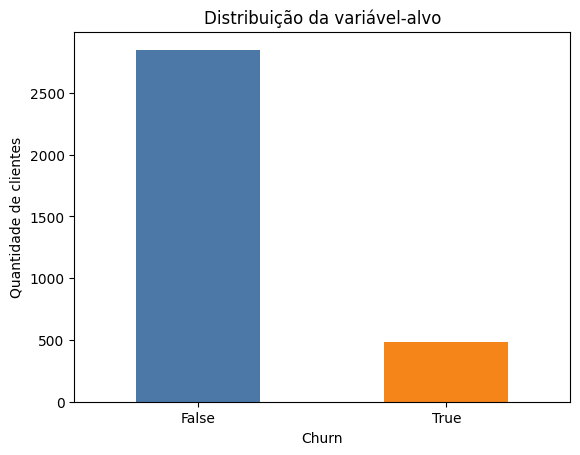

In [6]:
ax = target_summary.set_index("churn")["clientes"].plot(kind="bar", color=["#4C78A8", "#F58518"])
ax.set_title("Distribuição da variável-alvo")
ax.set_xlabel("Churn")
ax.set_ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.show()

A variável-alvo é desbalanceada: a maioria dos clientes não cancelou. Esse ponto será importante na modelagem, porque acurácia isolada pode não ser uma boa métrica para avaliar o modelo.

In [7]:
def churn_rate_by(column):
    result = (
        df.groupby(column)["churn"]
        .agg(clientes="count", taxa_churn="mean")
        .reset_index()
    )
    result["taxa_churn_pct"] = result["taxa_churn"] * 100
    return result.drop(columns="taxa_churn")

churn_rate_by("international plan")

,international plan,clientes,taxa_churn_pct
0,no,3010,11.50
1,yes,323,42.41


In [8]:
churn_rate_by("voice mail plan")

,voice mail plan,clientes,taxa_churn_pct
0,no,2411,16.72
1,yes,922,8.68


In [9]:
churn_rate_by("customer service calls")

,customer service calls,clientes,taxa_churn_pct
0,0,697,13.20
1,1,1181,10.33
2,2,759,11.46
3,3,429,10.26
4,4,166,45.78
5,5,66,60.61
6,6,22,63.64
7,7,9,55.56
8,8,2,50.00
9,9,2,100.00


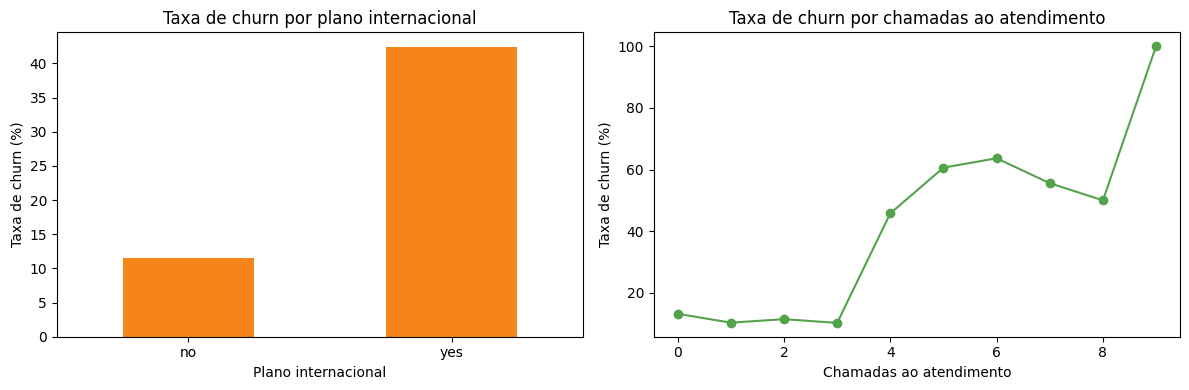

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

intl = churn_rate_by("international plan").set_index("international plan")
intl["taxa_churn_pct"].plot(kind="bar", ax=axes[0], color="#F58518")
axes[0].set_title("Taxa de churn por plano internacional")
axes[0].set_xlabel("Plano internacional")
axes[0].set_ylabel("Taxa de churn (%)")
axes[0].tick_params(axis="x", rotation=0)

service = churn_rate_by("customer service calls").set_index("customer service calls")
service["taxa_churn_pct"].plot(kind="line", marker="o", ax=axes[1], color="#54A24B")
axes[1].set_title("Taxa de churn por chamadas ao atendimento")
axes[1].set_xlabel("Chamadas ao atendimento")
axes[1].set_ylabel("Taxa de churn (%)")

plt.tight_layout()
plt.show()

Dois padrões merecem destaque:

- clientes com plano internacional têm taxa de churn muito maior;
- clientes com 4 ou mais chamadas ao atendimento apresentam aumento forte na taxa de churn.

In [11]:
numeric_focus = [
    "account length",
    "number vmail messages",
    "total day minutes",
    "total eve minutes",
    "total night minutes",
    "total intl minutes",
    "customer service calls",
]

df.groupby("churn")[numeric_focus].mean().T

churn,False,True
account length,100.79,102.66
number vmail messages,8.60,5.12
total day minutes,175.18,206.91
total eve minutes,199.04,212.41
total night minutes,200.13,205.23
total intl minutes,10.16,10.70
customer service calls,1.45,2.23


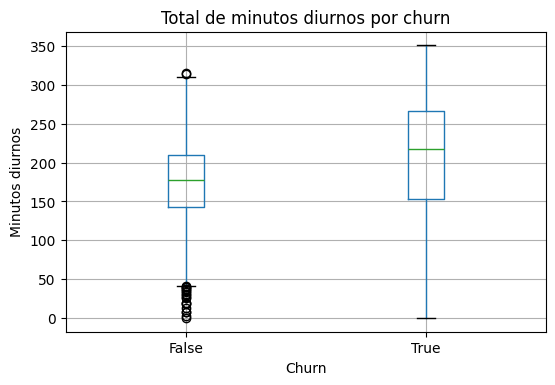

In [12]:
df.boxplot(column="total day minutes", by="churn", figsize=(6, 4))
plt.title("Total de minutos diurnos por churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Minutos diurnos")
plt.show()

In [13]:
numeric_df = df.select_dtypes(include="number").copy()
numeric_df["churn"] = df["churn"].astype(int)

corr_with_churn = (
    numeric_df.corr(numeric_only=True)["churn"]
    .drop("churn")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

corr_with_churn

customer service calls    0.21
total day minutes         0.21
total day charge          0.21
total eve minutes         0.09
total eve charge          0.09
number vmail messages    -0.09
total intl charge         0.07
total intl minutes        0.07
total intl calls         -0.05
total night charge        0.04
total night minutes       0.04
total day calls           0.02
account length            0.02
total eve calls           0.01
area code                 0.01
total night calls         0.01
Name: churn, dtype: float64

In [14]:
charge_pairs = pd.DataFrame(
    [
        {
            "periodo": period,
            "correlacao_minutos_cobranca": df[f"total {period} minutes"].corr(df[f"total {period} charge"]),
        }
        for period in ["day", "eve", "night", "intl"]
    ]
)

charge_pairs

,periodo,correlacao_minutos_cobranca
0,day,1.00
1,eve,1.00
2,night,1.00
3,intl,1.00


## Localização (estado) — teste da hipótese H4

A hipótese **H4** afirma que a localização (`state`) tem pouco poder preditivo isoladamente. Diferente das variáveis anteriores, `state` é categórica com muitas categorias (51), então a correlação linear não é adequada. Para avaliar a associação entre `state` e `churn`, observamos (1) a taxa de churn por estado, (2) o tamanho da amostra em cada grupo e (3) o **teste qui-quadrado de independência**.

In [15]:
state_churn = churn_rate_by("state").sort_values("taxa_churn_pct", ascending=False)

# 5 estados com maior e 5 com menor taxa de churn
pd.concat([state_churn.head(5), state_churn.tail(5)])

,state,clientes,taxa_churn_pct
4,CA,34,26.47
31,NJ,68,26.47
43,TX,72,25.00
20,MD,70,24.29
40,SC,60,23.33
12,IA,44,6.82
45,VA,77,6.49
3,AZ,64,6.25
0,AK,52,5.77
11,HI,53,5.66


In [16]:
churners_por_estado = state_churn["taxa_churn_pct"] / 100 * state_churn["clientes"]

state_sample = pd.DataFrame(
    {
        "indicador": [
            "estados",
            "min clientes/estado",
            "mediana clientes/estado",
            "max clientes/estado",
            "media churners/estado",
        ],
        "valor": [
            f"{state_churn['state'].nunique()}",
            f"{int(state_churn['clientes'].min())}",
            f"{state_churn['clientes'].median():.0f}",
            f"{int(state_churn['clientes'].max())}",
            f"{churners_por_estado.mean():.2f}",
        ],
    }
)

state_sample

,indicador,valor
0,estados,51
1,min clientes/estado,34
2,mediana clientes/estado,65
3,max clientes/estado,106
4,media churners/estado,9.47


In [17]:
from scipy.stats import chi2_contingency

contingencia = pd.crosstab(df["state"], df["churn"])
chi2, p_valor, gl, esperado = chi2_contingency(contingencia)
n = int(contingencia.to_numpy().sum())
cramers_v = (chi2 / (n * (min(contingencia.shape) - 1))) ** 0.5

teste_h4 = pd.DataFrame(
    {
        "indicador": [
            "qui-quadrado (chi2)",
            "graus de liberdade",
            "p-valor",
            "Cramer's V",
            "celulas esperadas < 5",
        ],
        "valor": [
            f"{chi2:.2f}",
            f"{gl}",
            f"{p_valor:.4f}",
            f"{cramers_v:.3f}",
            f"{int((esperado < 5).sum())} de {esperado.size}",
        ],
    }
)

teste_h4

,indicador,valor
0,qui-quadrado (chi2),83.04
1,graus de liberdade,50
2,p-valor,0.0023
3,Cramer's V,0.158
4,celulas esperadas < 5,1 de 102


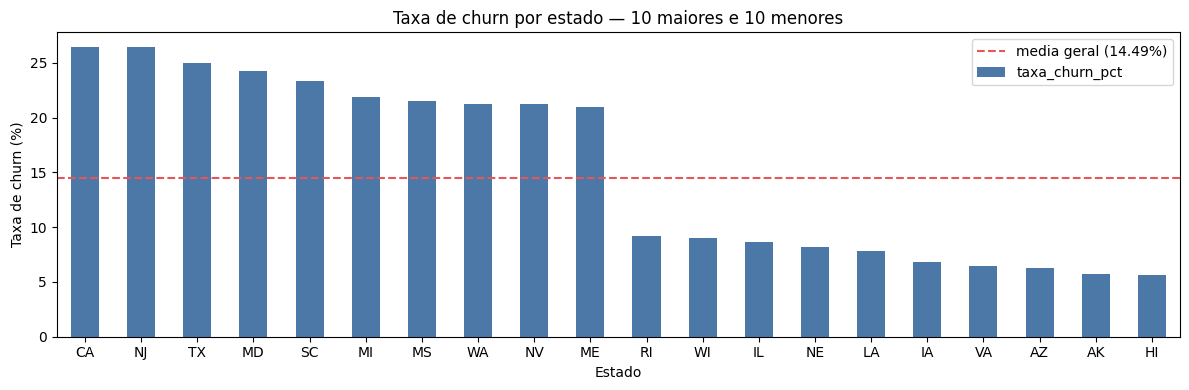

In [18]:
top_bottom = pd.concat([state_churn.head(10), state_churn.tail(10)]).set_index("state")
baseline = df["churn"].mean() * 100

ax = top_bottom["taxa_churn_pct"].plot(kind="bar", figsize=(12, 4), color="#4C78A8")
ax.axhline(baseline, color="#E45756", linestyle="--", label=f"media geral ({baseline:.2f}%)")
ax.set_title("Taxa de churn por estado — 10 maiores e 10 menores")
ax.set_xlabel("Estado")
ax.set_ylabel("Taxa de churn (%)")
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

A taxa de churn varia de forma aparente entre estados (de cerca de **5,7%** a **26,5%**), e o teste qui-quadrado indica que essa variação é **estatisticamente significativa** (χ² = 83,04, gl = 50, p = 0,0023), sendo um teste válido (apenas 1 de 102 células com frequência esperada abaixo de 5).

No entanto, o tamanho do efeito é **pequeno** (Cramér's V ≈ 0,16) e cada estado possui poucos registros (mediana de 65 clientes e cerca de 9 churners por estado). Existe, portanto, algum sinal associado à localização, mas ele é **fraco e instável** quando usado isoladamente, além de envolver alta cardinalidade (51 categorias) com risco de overfitting.

Assim, **H4 é refinada**: a localização não é um preditor central como `international plan` ou `customer service calls`, mas também não é puro ruído. Na etapa de modelagem, o estado deve ser usado com cautela — agregado ou descartado — e não como variável principal.

## Conclusões da exploração

A exploração inicial mostra que os dados estão limpos, sem valores ausentes ou duplicados. O principal cuidado é o desbalanceamento da variável-alvo.

As variáveis que mais parecem associadas ao churn nesta etapa são:

- `international plan`;
- `customer service calls`;
- `total day minutes`;
- `voice mail plan`;
- `number vmail messages`.

Também foi observado que as colunas de cobrança são redundantes em relação às colunas de minutos. Na etapa de modelagem, será necessário decidir quais dessas variáveis manter para evitar duplicidade de informação.

A próxima etapa do AGEMC será **M — Model the Data**, onde será introduzida a originalidade do projeto.